In [3]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")
val_df = pd.read_csv("data/val.csv")

In [4]:
import pandas as pd
import optuna
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report, confusion_matrix

target_column = 'Churn'

X_train_new = train_df.drop(target_column, axis=1)
y_train_new = train_df[target_column]

X_val_new = val_df.drop(target_column, axis=1)
y_val_new = val_df[target_column]

X_test_new = test_df.drop(target_column, axis=1)
y_test_new = test_df[target_column]

# optuna for hyperparameter tuning
def objective(trial):
    params = {
        'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42,
        'n_jobs': -1, 'tree_method': 'hist',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0)
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train_new, y_train_new)
    y_pred = model.predict(X_val_new)
    score = f1_score(y_val_new, y_pred, pos_label=1)
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)

print("BEST F1-SCORE:", study.best_value)
print("BEST PARAMETERS:", study.best_params)

best_params_v6 = study.best_params
best_params_v6['n_jobs'] = -1

best_xgb_v6_final = xgb.XGBClassifier(**best_params_v6, objective='binary:logistic', random_state=42)
# train on combined training and validation data
X_train_full = pd.concat([X_train_new, X_val_new], ignore_index=True)
y_train_full = pd.concat([y_train_new, y_val_new], ignore_index=True)
best_xgb_v6_final.fit(X_train_full, y_train_full)

# evaluate on test set
y_pred_v6 = best_xgb_v6_final.predict(X_test_new)
print("\nMODEL CONFUSION MATRIX:")
print(confusion_matrix(y_test_new, y_pred_v6))
print("\nMODEL CLASSIFICATION REPORT:")
print(classification_report(y_test_new, y_pred_v6, target_names=['Not Churned (0)', 'Churned (1)']))

[I 2025-10-12 07:58:35,185] A new study created in memory with name: no-name-6703ebec-4072-4ae2-96b9-db55a7c8f010
[I 2025-10-12 07:58:39,275] Trial 0 finished with value: 0.4251111059403867 and parameters: {'n_estimators': 165, 'learning_rate': 0.03651890890055745, 'max_depth': 11, 'subsample': 0.7161532722658517, 'colsample_bytree': 0.8505574789358382, 'scale_pos_weight': 5.517097737850395}. Best is trial 0 with value: 0.4251111059403867.
[I 2025-10-12 07:58:47,346] Trial 1 finished with value: 0.2977896213905946 and parameters: {'n_estimators': 785, 'learning_rate': 0.03770920180745676, 'max_depth': 5, 'subsample': 0.6661242519058099, 'colsample_bytree': 0.7664352408130455, 'scale_pos_weight': 8.74302807252326}. Best is trial 0 with value: 0.4251111059403867.
[I 2025-10-12 07:59:06,229] Trial 2 finished with value: 0.4104867095521301 and parameters: {'n_estimators': 796, 'learning_rate': 0.0514675147861071, 'max_depth': 12, 'subsample': 0.6855636949121028, 'colsample_bytree': 0.81572

BEST F1-SCORE: 0.4642624375407343
BEST PARAMETERS: {'n_estimators': 259, 'learning_rate': 0.05485008417792812, 'max_depth': 10, 'subsample': 0.8695382075730154, 'colsample_bytree': 0.8194815708067952, 'scale_pos_weight': 2.2824762408009693}

MODEL CONFUSION MATRIX:
[[139604   9141]
 [ 10892   8454]]

MODEL CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

Not Churned (0)       0.93      0.94      0.93    148745
    Churned (1)       0.48      0.44      0.46     19346

       accuracy                           0.88    168091
      macro avg       0.70      0.69      0.70    168091
   weighted avg       0.88      0.88      0.88    168091



In [5]:
import joblib
import shap

# save model
joblib.dump(best_xgb_v6_final, 'xgb_clean.joblib')

# lightweight proxy model for faster explanations
proxy_params = {
    'objective': 'binary:logistic', 'random_state': 42,
    'n_jobs': -1, 'n_estimators': 50, 'max_depth': 5
}
proxy_model = xgb.XGBClassifier(**proxy_params)
proxy_model.fit(X_train_new, y_train_new)

proxy_explainer = shap.TreeExplainer(proxy_model)
joblib.dump(proxy_explainer, 'shap_explainer_clean.joblib')

X_test_new.to_csv('X_test_processed.csv', index=False)
y_test_df = pd.DataFrame(y_test_new)
y_test_df.to_csv('y_test_processed.csv', index=False)

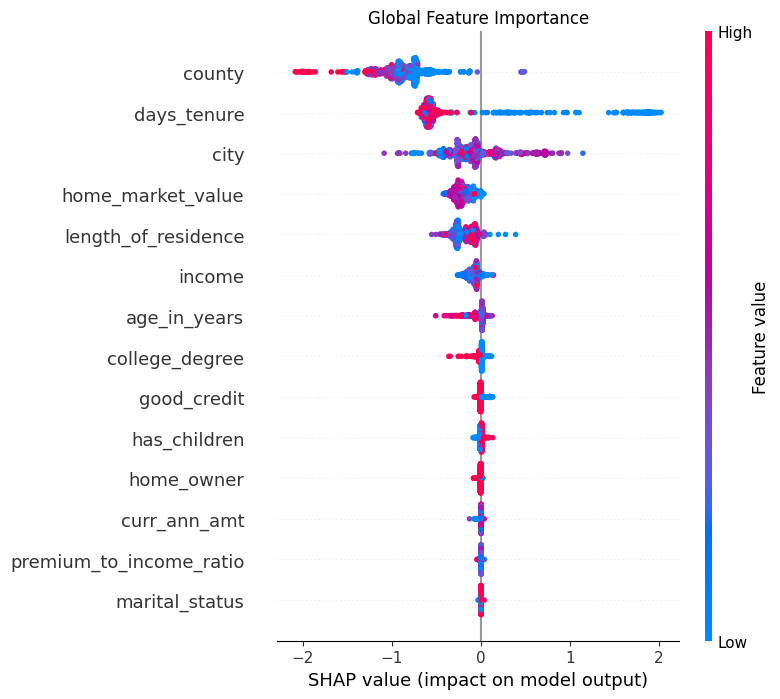

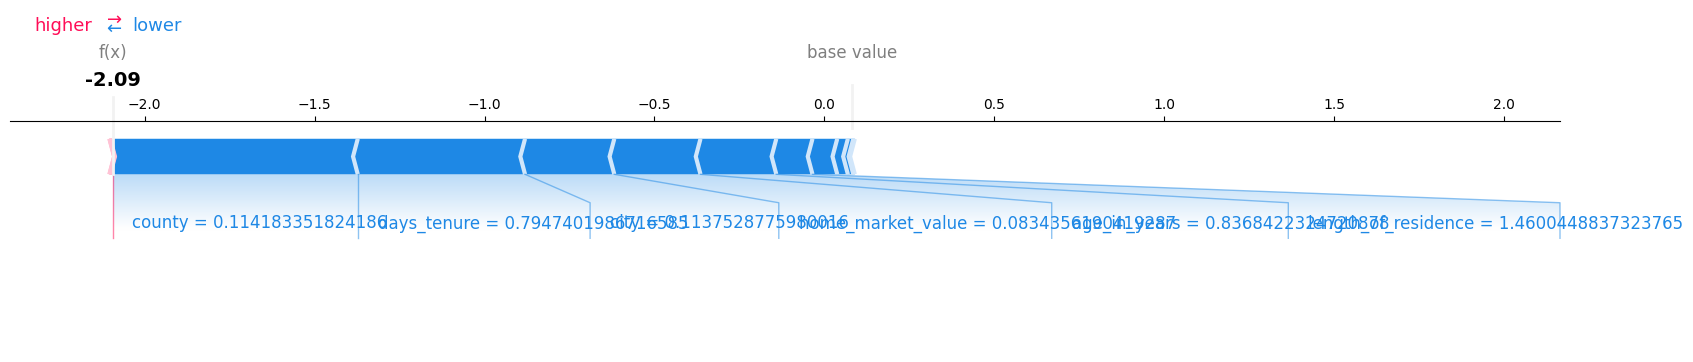

In [6]:
import matplotlib.pyplot as plt

# use a sample of the test data
X_test_sample = X_test_new.sample(n=1000, random_state=42)
shap_values_sample = proxy_explainer.shap_values(X_test_sample)

# global feature importance
plt.title('Global Feature Importance')
shap.summary_plot(shap_values_sample, X_test_sample, show=False)
plt.savefig('shap_global_importance.png', bbox_inches='tight')
plt.show()

# single prediction explanation
shap.initjs()
shap.force_plot(
    proxy_explainer.expected_value,
    shap_values_sample[0,:],
    X_test_sample.iloc[[0]],
    matplotlib=True,
    show=False
)
plt.savefig('shap_single_prediction.png', bbox_inches='tight')
plt.show()

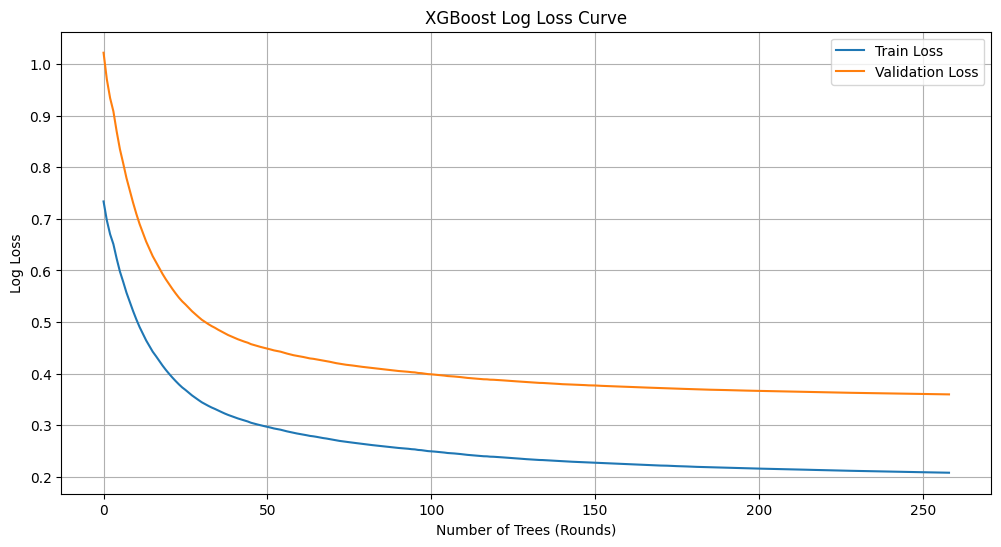

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

best_xgb_v6_final.fit(
    X_train_new,
    y_train_new,
    eval_set=[(X_train_new, y_train_new), (X_val_new, y_val_new)],
    verbose=False
)

results = best_xgb_v6_final.evals_result()
train_loss = results['validation_0']['logloss']
val_loss = results['validation_1']['logloss']

# plot loss curve
epochs = len(train_loss)
x_axis = range(0, epochs)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x_axis, train_loss, label='Train Loss')
ax.plot(x_axis, val_loss, label='Validation Loss')

ax.legend()
plt.ylabel('Log Loss')
plt.xlabel('Number of Trees (Rounds)')
plt.title('XGBoost Log Loss Curve')
plt.grid(True)
plt.show()